<a href="https://colab.research.google.com/github/Bishti04062005/House_price_predict_model/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Path to dataset files: /kaggle/input/housing-prices-dataset


In [38]:
import os

print(os.listdir(path))

['Housing.csv']


In [39]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB
None
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0

In [40]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, 'Housing.csv'))

# Convert 'yes'/'no' columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Convert 'furnishingstatus' to numerical using ordinal mapping
df['furnishingstatus'] = df['furnishingstatus'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 2  
1                 2  
2                 1  
3                 2  
4                 2  


In [41]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (436, 12)
X_test shape: (109, 12)
y_train shape: (436,)
y_test shape: (109,)


In [42]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


In [43]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

print("Linear Regression model trained and predictions made.")

Linear Regression model trained and predictions made.


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Absolute Error (MAE): 979679.69
Mean Squared Error (MSE): 1771751116594.04
R-squared (R2) Score: 0.65


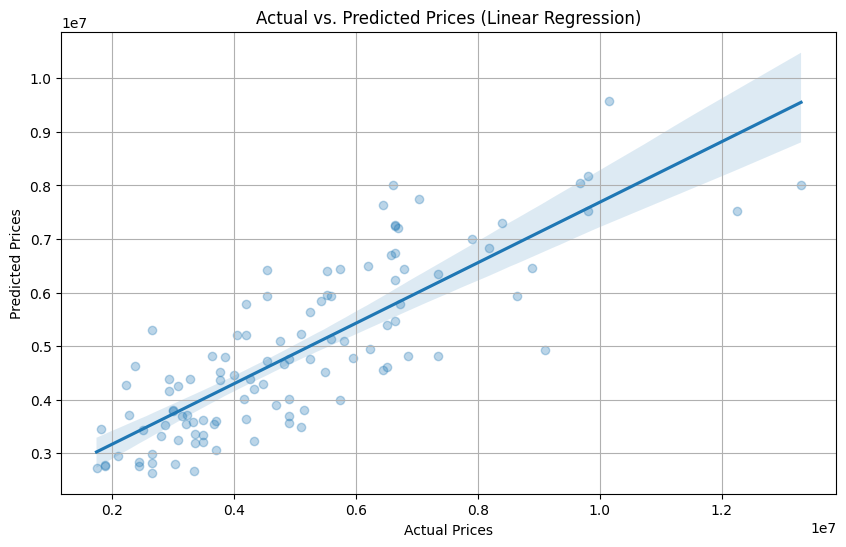

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3})
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Prices (Linear Regression)")
plt.grid(True)
plt.show()

In [46]:
feature_names = X_train.columns
coefficients = model.coef_

coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
display(coeff_df.sort_values(by='Coefficient', ascending=False))

,Feature,Coefficient
2,bathrooms,523153.382843
0,area,519288.130105
8,airconditioning,362446.186466
3,stories,348177.113610
10,prefarea,266661.049149
9,parking,192786.985891
6,basement,188462.048566
11,furnishingstatus,158183.270169
7,hotwaterheating,150570.028279
4,mainroad,128115.927978


In [47]:
import numpy as np

# Define the features for a new house (example values)
# You can modify these values to get a prediction for a different house
new_house_features = {
    'area': 6000,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 'yes', # 'yes' or 'no'
    'guestroom': 'no',  # 'yes' or 'no'
    'basement': 'yes',  # 'yes' or 'no'
    'hotwaterheating': 'no', # 'yes' or 'no'
    'airconditioning': 'yes', # 'yes' or 'no'
    'parking': 1,
    'prefarea': 'no',   # 'yes' or 'no'
    'furnishingstatus': 'semi-furnished' # 'unfurnished', 'semi-furnished', 'furnished'
}

# Convert to DataFrame
new_house_df = pd.DataFrame([new_house_features])

# Apply the same binary and ordinal mappings
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    new_house_df[col] = new_house_df[col].map({'yes': 1, 'no': 0})

new_house_df['furnishingstatus'] = new_house_df['furnishingstatus'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})

# Ensure the order of columns matches the training data
new_house_df = new_house_df[X.columns] # X.columns holds the original feature order

# Scale the new house features using the *fitted* scaler
new_house_scaled = scaler.transform(new_house_df)

# Predict the price
predicted_price = model.predict(new_house_scaled)

print(f"Predicted price for the new house: ${predicted_price[0]:,.2f}")

Predicted price for the new house: $6,511,473.98


In [49]:
import pandas as pd

report_filename = "model_report.csv"

report_data = {
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'R-squared (R2) Score', 'Predicted House Price'],
    'Value': [f'{mae:.2f}', f'{mse:.2f}', f'{r2:.2f}', f'{predicted_price[0]:,.2f}']
}

report_df = pd.DataFrame(report_data)
report_df.to_csv(report_filename, index=False)

print(f"Report saved to {report_filename}")

Report saved to model_report.csv


In [52]:
from google.colab import files

files.download('model_report.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>